In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [2]:
original_df = pd.read_csv(r"C:\MASTERS\FOML\202618026_AumTailor_DS605\202618026_Challenge_01\train.csv")
test_df = pd.read_csv(r"C:\MASTERS\FOML\202618026_AumTailor_DS605\202618026_Challenge_01\test.csv")

In [3]:
print(original_df.shape)
original_df.head()
original_df.info()
original_df.describe()
original_df.dtypes

(9864, 19)
<class 'pandas.DataFrame'>
RangeIndex: 9864 entries, 0 to 9863
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Session_ID               9864 non-null   int64  
 1   Administrative           9864 non-null   int64  
 2   Administrative_Duration  9372 non-null   float64
 3   Informational            9864 non-null   int64  
 4   Informational_Duration   9864 non-null   float64
 5   ProductRelated           9864 non-null   int64  
 6   ProductRelated_Duration  9864 non-null   float64
 7   BounceRates              9864 non-null   float64
 8   ExitRates                9173 non-null   float64
 9   PageValues               9864 non-null   float64
 10  SpecialDay               9864 non-null   float64
 11  Month                    9864 non-null   str    
 12  OperatingSystems         9864 non-null   int64  
 13  Browser                  9864 non-null   int64  
 14  Region                  

Session_ID                   int64
Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                          str
OperatingSystems             int64
Browser                      int64
Region                     float64
TrafficType                float64
VisitorType                    str
Weekend                       bool
Revenue                       bool
dtype: object

In [4]:
original_df.isnull().sum()
(original_df.isnull().sum() / len(original_df)) * 100

Session_ID                 0.000000
Administrative             0.000000
Administrative_Duration    4.987835
Informational              0.000000
Informational_Duration     0.000000
ProductRelated             0.000000
ProductRelated_Duration    0.000000
BounceRates                0.000000
ExitRates                  7.005272
PageValues                 0.000000
SpecialDay                 0.000000
Month                      0.000000
OperatingSystems           0.000000
Browser                    0.000000
Region                     5.991484
TrafficType                7.998783
VisitorType                3.994323
Weekend                    0.000000
Revenue                    0.000000
dtype: float64

In [5]:
original_df['Revenue'].value_counts()
original_df['Revenue'].value_counts(normalize=True) * 100

Revenue
False    83.242092
True     16.757908
Name: proportion, dtype: float64

In [6]:
target_col = 'Revenue'
id_col = 'Session_ID'

y = original_df[target_col]
X = original_df.drop(columns=[target_col, id_col])

num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'string', 'bool']).columns.tolist()

print(num_cols)
print(cat_cols)

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType']
['Month', 'VisitorType', 'Weekend']


In [7]:
y = y.astype(int)

X['Weekend'] = X['Weekend'].astype(int)
test_df['Weekend'] = test_df['Weekend'].astype(int)

cat_cols.remove('Weekend')
num_cols.append('Weekend')

print(num_cols)
print(cat_cols)

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'Weekend']
['Month', 'VisitorType']


In [8]:
from sklearn.impute import SimpleImputer, KNNImputer

# check which num_cols actually have missing values
print(X[num_cols].isnull().sum())
print(X[cat_cols].isnull().sum())

Administrative               0
Administrative_Duration    492
Informational                0
Informational_Duration       0
ProductRelated               0
ProductRelated_Duration      0
BounceRates                  0
ExitRates                  691
PageValues                   0
SpecialDay                   0
OperatingSystems             0
Browser                      0
Region                     591
TrafficType                789
Weekend                      0
dtype: int64
Month            0
VisitorType    394
dtype: int64


In [9]:
num_imputer = KNNImputer(n_neighbors=5)
X[num_cols] = num_imputer.fit_transform(X[num_cols])

In [10]:
cat_imputer = SimpleImputer(strategy='most_frequent')
X[cat_cols] = cat_imputer.fit_transform(X[cat_cols])

In [11]:
test_df[num_cols] = num_imputer.transform(test_df[num_cols])
test_df[cat_cols] = cat_imputer.transform(test_df[cat_cols])

In [12]:
print(X.isnull().sum().sum())
print(test_df[num_cols + cat_cols].isnull().sum().sum())

0
0


In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_cat_encoded = encoder.fit_transform(X[cat_cols])
test_cat_encoded = encoder.transform(test_df[cat_cols])

encoded_cols = encoder.get_feature_names_out(cat_cols)

X_cat_df = pd.DataFrame(X_cat_encoded, columns=encoded_cols, index=X.index)
test_cat_df = pd.DataFrame(test_cat_encoded, columns=encoded_cols, index=test_df.index)

In [14]:
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[num_cols])
test_num_scaled = scaler.transform(test_df[num_cols])

X_num_df = pd.DataFrame(X_num_scaled, columns=num_cols, index=X.index)
test_num_df = pd.DataFrame(test_num_scaled, columns=num_cols, index=test_df.index)

In [15]:
processed_df = pd.concat([X_num_df, X_cat_df], axis=1)
processed_df[target_col] = y.values

X_test_final = pd.concat([test_num_df, test_cat_df], axis=1)

In [16]:
X_features = processed_df.drop(columns=[target_col])
y_target = processed_df[target_col]

X_train, X_val, y_train, y_val = train_test_split(
    X_features, y_target, test_size=0.2, stratify=y_target, random_state=42
)

model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Defaul

Train Accuracy: 0.8502090989735142
Val Accuracy: 0.8494678155093766
Precision: 0.5400943396226415
Recall: 0.6918429003021148
F1 Score: 0.6066225165562914


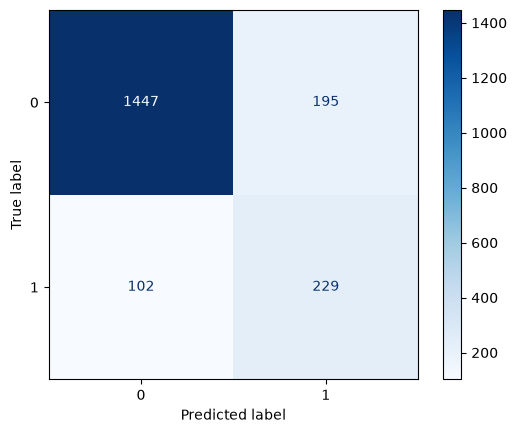

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_train_pred = model.predict(X_train)
y_val_pred = model.predict(X_val)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Val Accuracy:", accuracy_score(y_val, y_val_pred))
print("Precision:", precision_score(y_val, y_val_pred))
print("Recall:", recall_score(y_val, y_val_pred))
print("F1 Score:", f1_score(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.show()

In [18]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_features, y_target)

predictions = model.predict(X_test_final)
print(predictions[:10])
print(len(predictions))

[0 0 1 0 0 0 0 0 0 0]
2466


In [19]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_features, y_target)

predictions = model.predict(X_test_final)
print(predictions[:10])
print(len(predictions))
print(test_df.columns.tolist())
print(test_df.shape)

[0 0 1 0 0 0 0 0 0 0]
2466
['Session_ID', 'Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend']
(2466, 18)


In [20]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_features, y_target)

predictions = model.predict(X_test_final)

In [21]:
predictions = predictions.astype(bool)
print(predictions[:10])
print(len(predictions))

[False False  True False False False False False False False]
2466


In [22]:
print(type(original_df), original_df.shape)
print(type(processed_df), processed_df.shape)
print(type(model))
print(type(predictions), len(predictions))
print(type(test_df), test_df.shape)

<class 'pandas.DataFrame'> (9864, 19)
<class 'pandas.DataFrame'> (9864, 29)
<class 'sklearn.linear_model._logistic.LogisticRegression'>
<class 'numpy.ndarray'> 2466
<class 'pandas.DataFrame'> (2466, 18)


In [23]:
original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (
    processed_rows / original_rows
) * 100

final_model = model

if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_

if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]

model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],
    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat(
    [checkpoints, prediction_output],
    ignore_index=True
)

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully.")
print(checkpoints)

submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  29
6  row_retained_percent               100.0
7            model_name  LogisticRegression


In [24]:
from sklearn.model_selection import cross_val_score

check_model = LogisticRegression(max_iter=1000, class_weight='balanced')
cv_scores = cross_val_score(check_model, X_features, y_target, cv=5, scoring='accuracy')

print("CV Accuracy scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Accuracy scores: [0.83781044 0.84034465 0.8469336  0.82361885 0.84533469]
Mean CV Accuracy: 0.8388084475099442


CV Accuracy (5-fold): [0.83781044 0.84034465 0.8469336  0.82361885 0.84533469]
Mean CV Accuracy: 0.8388084475099442
Std CV Accuracy: 0.008278763487419172

Accuracy: 0.8388077858880778
Precision: 0.5138461538461538
Recall: 0.7071990320629159
F1 Score: 0.595213849287169

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      8211
           1       0.51      0.71      0.60      1653

    accuracy                           0.84      9864
   macro avg       0.73      0.79      0.75      9864
weighted avg       0.87      0.84      0.85      9864



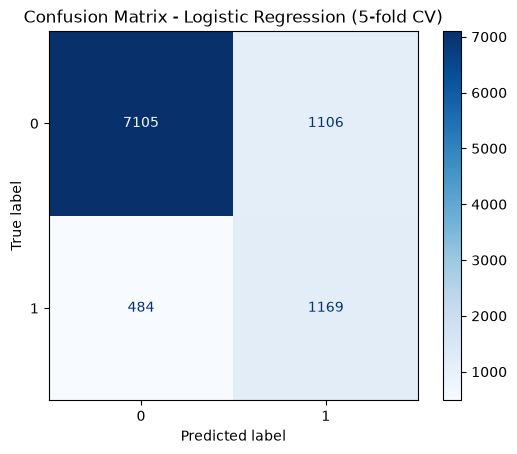


ROC-AUC Score: 0.8612415744066637


In [25]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt

eval_model = LogisticRegression(max_iter=1000, class_weight='balanced')

cv_scores = cross_val_score(eval_model, X_features, y_target, cv=5, scoring='accuracy')
print("CV Accuracy (5-fold):", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

y_pred_cv = cross_val_predict(eval_model, X_features, y_target, cv=5)

print("\nAccuracy:", accuracy_score(y_target, y_pred_cv))
print("Precision:", precision_score(y_target, y_pred_cv))
print("Recall:", recall_score(y_target, y_pred_cv))
print("F1 Score:", f1_score(y_target, y_pred_cv))

print("\nClassification Report:")
print(classification_report(y_target, y_pred_cv))

cm = confusion_matrix(y_target, y_pred_cv)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (5-fold CV)")
plt.show()

y_proba_cv = cross_val_predict(eval_model, X_features, y_target, cv=5, method='predict_proba')[:, 1]
auc = roc_auc_score(y_target, y_proba_cv)
print("\nROC-AUC Score:", auc)

In [26]:
model = LogisticRegression(max_iter=1000)
model.fit(X_features, y_target)
predictions = model.predict(X_test_final)
predictions = predictions.astype(bool)

In [27]:
eval_model = LogisticRegression(max_iter=1000)

CV Accuracy (5-fold): [0.86974151 0.86822098 0.86264572 0.86619361 0.86916836]
Mean CV Accuracy: 0.8671940363261023
Std CV Accuracy: 0.002574111052488022

Accuracy: 0.8671938361719383
Precision: 0.7352537722908093
Recall: 0.32425892316999394
F1 Score: 0.45004198152812763

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.92      8211
           1       0.74      0.32      0.45      1653

    accuracy                           0.87      9864
   macro avg       0.81      0.65      0.69      9864
weighted avg       0.85      0.87      0.84      9864



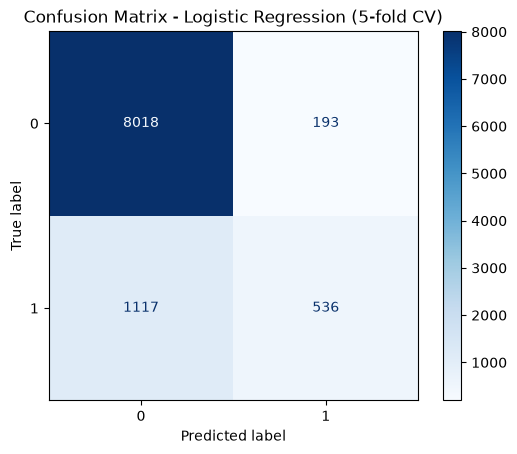


ROC-AUC Score: 0.8531227530860842


In [28]:
cv_scores = cross_val_score(eval_model, X_features, y_target, cv=5, scoring='accuracy')
print("CV Accuracy (5-fold):", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())
print("Std CV Accuracy:", cv_scores.std())

y_pred_cv = cross_val_predict(eval_model, X_features, y_target, cv=5)

print("\nAccuracy:", accuracy_score(y_target, y_pred_cv))
print("Precision:", precision_score(y_target, y_pred_cv))
print("Recall:", recall_score(y_target, y_pred_cv))
print("F1 Score:", f1_score(y_target, y_pred_cv))

print("\nClassification Report:")
print(classification_report(y_target, y_pred_cv))

cm = confusion_matrix(y_target, y_pred_cv)
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (5-fold CV)")
plt.show()

y_proba_cv = cross_val_predict(eval_model, X_features, y_target, cv=5, method='predict_proba')[:, 1]
auc = roc_auc_score(y_target, y_proba_cv)
print("\nROC-AUC Score:", auc)

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_features, y_target)
predictions = model.predict(X_test_final)
predictions = predictions.astype(bool)

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_features, y_target)

predictions = model.predict(X_test_final)
predictions = predictions.astype(bool)

original_missing = original_df.isnull().sum().sum()
processed_missing = processed_df.isnull().sum().sum()

original_rows, original_columns = original_df.shape
processed_rows, processed_columns = processed_df.shape

row_retained_percent = (
    processed_rows / original_rows
) * 100

final_model = model

if hasattr(final_model, "best_estimator_"):
    final_model = final_model.best_estimator_

if hasattr(final_model, "steps"):
    final_model = final_model.steps[-1][1]

model_name = final_model.__class__.__name__

checkpoints = pd.DataFrame({
    "id": [
        "original_missing",
        "processed_missing",
        "original_rows",
        "processed_rows",
        "original_columns",
        "processed_columns",
        "row_retained_percent",
        "model_name"
    ],
    "value": [
        original_missing,
        processed_missing,
        original_rows,
        processed_rows,
        original_columns,
        processed_columns,
        round(row_retained_percent, 2),
        model_name
    ]
})

prediction_output = pd.DataFrame({
    "id": test_df["Session_ID"].astype(str),
    "value": np.asarray(predictions).astype(str)
})

submission = pd.concat(
    [checkpoints, prediction_output],
    ignore_index=True
)

submission.to_csv(
    "submission.csv",
    index=False
)

print("submission.csv created successfully.")
print(checkpoints)

submission.csv created successfully.
                     id               value
0      original_missing                2957
1     processed_missing                   0
2         original_rows                9864
3        processed_rows                9864
4      original_columns                  19
5     processed_columns                  29
6  row_retained_percent               100.0
7            model_name  LogisticRegression
